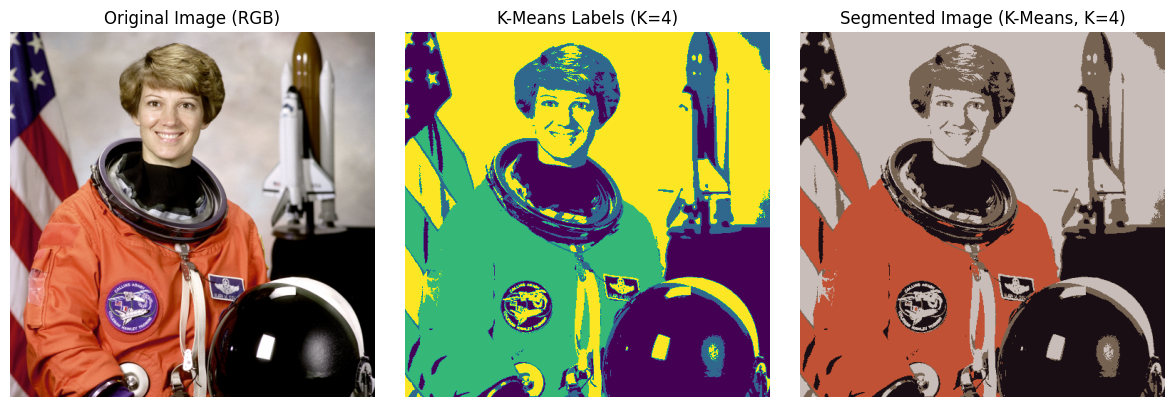

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro = data.astronaut()
# Konversi ke float untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape citra menjadi array piksel [jumlah_piksel, jumlah_fitur]
# Fitur bisa RGB atau Lab. Ruang warna Lab seringkali lebih baik untuk persepsi warna.
# Konversi ke Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
# Tentukan jumlah klaster (segmen) yang diinginkan, misal K=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10) # n_init='auto' jika versi sklearn baru
# Hiding FutureWarnings related to default value of n_init
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra tersegmentasi (warnai setiap segmen dengan warna rata-rata klaster)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    # Dapatkan piksel yang termasuk klaster k
    cluster_pixels = (pixel_labels == k)
    # Isi piksel tersebut di citra baru dengan warna pusat klaster k
    # Perlu reshape kembali cluster_pixels ke bentuk citra
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB untuk ditampilkan
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Menampilkan label klaster
ax[1].imshow(segmented_labels, cmap='viridis') # cmap bisa diganti
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Menampilkan citra hasil segmentasi K-Means
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

Tugas Lanjutan:
Amati hasil segmentasi K-Means. Apakah jumlah klaster (K) mempengaruhi hasil segmentasi secara signifikan? Cobalah mengubah nilai K. Apakah penggunaan ruang warna Lab membantu?

PENGARUH JUMLAH KLASTER (K) PADA SEGMENTASI K-MEANS


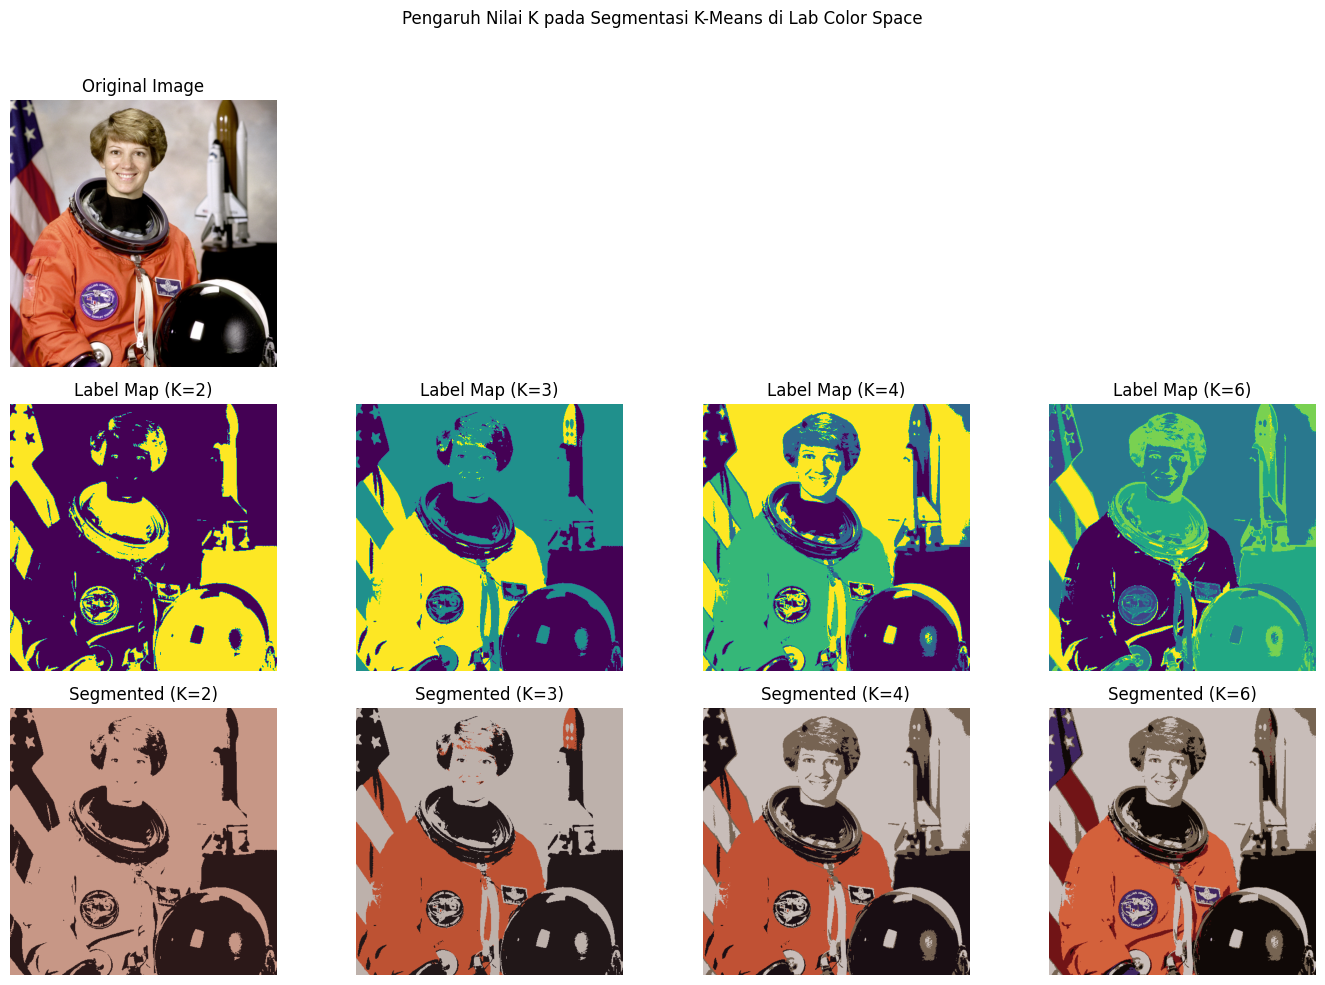


✓ OBSERVASI:
K=2: Hanya 2 warna dominan (terlalu sederhana)
K=3: 3 klaster (balance antara detail dan simplicity)
K=4: 4 klaster (detail lebih baik)
K=6: 6 klaster (terlalu banyak, fragmen kecil muncul)

✓ PENGARUH LAB COLOR SPACE:
- Lab memisahkan luminansi (L) dari chrominance (a,b)
- Lebih sesuai dengan persepsi visual manusia
- Hasil clustering lebih meaningful dibanding RGB


In [2]:
# Tugas Lanjutan: Pengaruh nilai K pada K-Means
print("=" * 60)
print("PENGARUH JUMLAH KLASTER (K) PADA SEGMENTASI K-MEANS")
print("=" * 60)

# Coba beberapa nilai K yang berbeda
k_values = [2, 3, 4, 6]
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for idx, k in enumerate(k_values):
    # Jalankan K-Means dengan K berbeda
    kmeans_k = KMeans(n_clusters=k, random_state=0, n_init=10)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        labels_k = kmeans_k.fit_predict(pixel_features)
    
    labels_k_reshaped = labels_k.reshape(rows, cols)
    
    # Buat citra tersegmentasi
    seg_k = np.zeros_like(image_lab)
    centers_k = kmeans_k.cluster_centers_
    for cl in range(k):
        mask_cl = (labels_k == cl)
        mask_cl_2d = mask_cl.reshape(rows, cols)
        seg_k[mask_cl_2d] = centers_k[cl]
    
    seg_k_rgb = lab2rgb(seg_k)
    
    # Baris 1: Original (hanya di index 0)
    if idx == 0:
        axes[0, 0].imshow(image_astro)
        axes[0, 0].set_title('Original Image')
        axes[0, 0].axis('off')
        for i in range(1, 4):
            fig.delaxes(axes[0, i])
    
    # Baris 2: Label maps
    axes[1, idx].imshow(labels_k_reshaped, cmap='viridis')
    axes[1, idx].set_title(f'Label Map (K={k})')
    axes[1, idx].axis('off')
    
    # Baris 3: Segmented images
    axes[2, idx].imshow(seg_k_rgb)
    axes[2, idx].set_title(f'Segmented (K={k})')
    axes[2, idx].axis('off')

plt.suptitle('Pengaruh Nilai K pada Segmentasi K-Means di Lab Color Space', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"\n✓ OBSERVASI:")
print(f"K=2: Hanya 2 warna dominan (terlalu sederhana)")
print(f"K=3: 3 klaster (balance antara detail dan simplicity)")
print(f"K=4: 4 klaster (detail lebih baik)")
print(f"K=6: 6 klaster (terlalu banyak, fragmen kecil muncul)")

print(f"\n✓ PENGARUH LAB COLOR SPACE:")
print(f"- Lab memisahkan luminansi (L) dari chrominance (a,b)")
print(f"- Lebih sesuai dengan persepsi visual manusia")
print(f"- Hasil clustering lebih meaningful dibanding RGB")